100%|██████████| 170M/170M [00:13<00:00, 12.5MB/s]


Epoch [1/30] | G: 7.0027 | D: 0.4144
Epoch [2/30] | G: 6.7931 | D: 0.4365
Epoch [3/30] | G: 6.4899 | D: 0.4335
Epoch [4/30] | G: 7.5309 | D: 0.3825
Epoch [5/30] | G: 5.9832 | D: 0.4101
Epoch [6/30] | G: 5.5967 | D: 0.3155
Epoch [7/30] | G: 5.8301 | D: 0.4234
Epoch [8/30] | G: 5.5312 | D: 0.4085
Epoch [9/30] | G: 5.0467 | D: 0.4450
Epoch [10/30] | G: 4.9752 | D: 0.3654
Epoch [11/30] | G: 5.4208 | D: 0.4735
Epoch [12/30] | G: 5.0547 | D: 0.3769
Epoch [13/30] | G: 5.0291 | D: 0.3400
Epoch [14/30] | G: 4.7958 | D: 0.4328
Epoch [15/30] | G: 5.1553 | D: 0.2431
Epoch [16/30] | G: 4.5761 | D: 0.3813
Epoch [17/30] | G: 4.8125 | D: 0.2625
Epoch [18/30] | G: 4.7819 | D: 0.3457
Epoch [19/30] | G: 5.0393 | D: 0.3911
Epoch [20/30] | G: 4.5576 | D: 0.3576
Epoch [21/30] | G: 4.6452 | D: 0.3156
Epoch [22/30] | G: 4.6248 | D: 0.2954
Epoch [23/30] | G: 4.8173 | D: 0.2418
Epoch [24/30] | G: 4.6495 | D: 0.3711
Epoch [25/30] | G: 4.6213 | D: 0.2723
Epoch [26/30] | G: 4.4197 | D: 0.3212
Epoch [27/30] | G: 4.

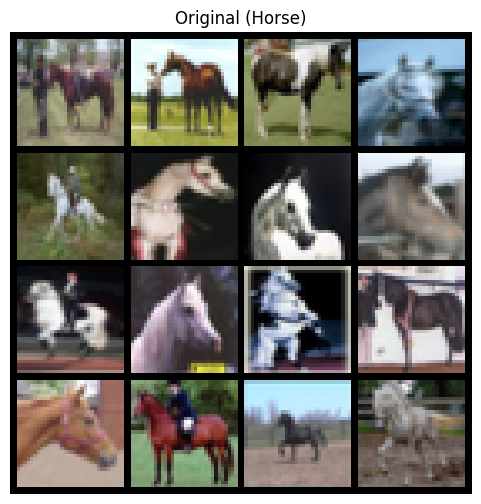

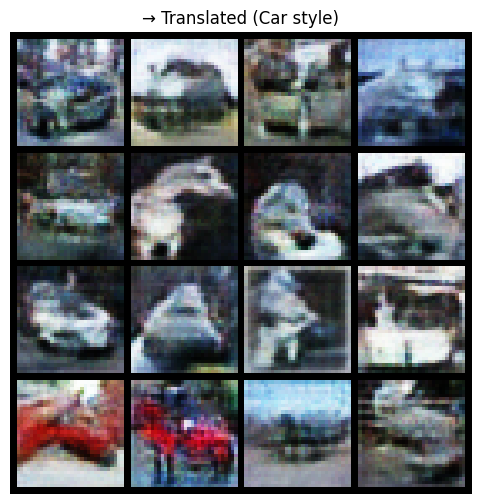

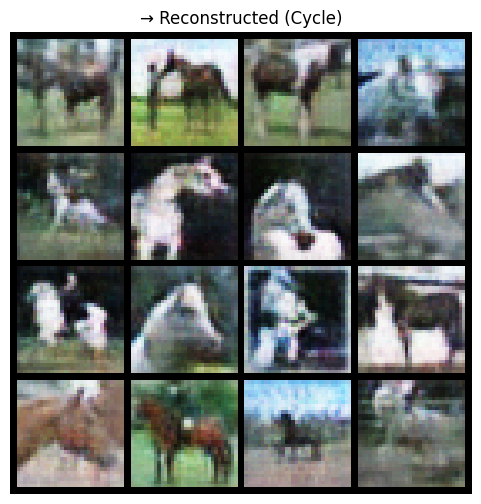

In [ ]:
# ==========================================
# Full CycleGAN (ResNet-based) on CIFAR-10
# ==========================================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import itertools
import random
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================
# Hyperparameters
# =====================
batch_size = 64
lr = 0.0002
num_epochs = 30
lambda_cycle = 10
lambda_identity = 5

# =====================
# Dataset (Domain split)
# =====================
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.CIFAR10(root="./data", train=True,
                                       transform=transform, download=True)

# Domain A = horse (7), Domain B = automobile (1)
domain_A = [img for img, label in dataset if label == 7]
domain_B = [img for img, label in dataset if label == 1]

loader_A = torch.utils.data.DataLoader(domain_A, batch_size=batch_size, shuffle=True)
loader_B = torch.utils.data.DataLoader(domain_B, batch_size=batch_size, shuffle=True)

# =====================
# ResNet Block
# =====================
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.InstanceNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.InstanceNorm2d(channels)
        )

    def forward(self, x):
        return x + self.block(x)

# =====================
# Generator (ResNet)
# =====================
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(3, 64, 7, 1, 3),
            nn.InstanceNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, 3, 2, 1),
            nn.InstanceNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 256, 3, 2, 1),
            nn.InstanceNorm2d(256),
            nn.ReLU(),

            # ResNet blocks
            ResBlock(256),
            ResBlock(256),
            ResBlock(256),
            ResBlock(256),
            ResBlock(256),
            ResBlock(256),

            nn.ConvTranspose2d(256, 128, 3, 2, 1, output_padding=1),
            nn.InstanceNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 3, 2, 1, output_padding=1),
            nn.InstanceNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 3, 7, 1, 3),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

# =====================
# Discriminator (PatchGAN)
# =====================
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.InstanceNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 1, 4, 1, 1)
        )

    def forward(self, x):
        return self.model(x)

# =====================
# Initialize
# =====================
G_AB = Generator().to(device)
G_BA = Generator().to(device)
D_A = Discriminator().to(device)
D_B = Discriminator().to(device)

criterion_GAN = nn.MSELoss()
criterion_cycle = nn.L1Loss()
criterion_identity = nn.L1Loss()

optimizer_G = optim.Adam(itertools.chain(G_AB.parameters(), G_BA.parameters()), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(itertools.chain(D_A.parameters(), D_B.parameters()), lr=lr, betas=(0.5, 0.999))

# =====================
# Replay Buffer (stabilization trick)
# =====================
class ReplayBuffer:
    def __init__(self, max_size=50):
        self.data = []
        self.max_size = max_size

    def push_and_pop(self, batch):
        result = []
        for img in batch:
            img = img.unsqueeze(0)
            if len(self.data) < self.max_size:
                self.data.append(img)
                result.append(img)
            else:
                if random.random() > 0.5:
                    idx = random.randint(0, self.max_size - 1)
                    result.append(self.data[idx])
                    self.data[idx] = img
                else:
                    result.append(img)
        return torch.cat(result)

fake_A_buffer = ReplayBuffer()
fake_B_buffer = ReplayBuffer()

# =====================
# Training Loop
# =====================
for epoch in range(num_epochs):
    for real_A, real_B in zip(loader_A, loader_B):

        real_A = real_A.to(device)
        real_B = real_B.to(device)

        valid = torch.ones((real_A.size(0), 1, 3, 3)).to(device)
        fake = torch.zeros((real_A.size(0), 1, 3, 3)).to(device)

        # ===== Generators =====
        optimizer_G.zero_grad()

        # Identity
        loss_id_A = criterion_identity(G_BA(real_A), real_A)
        loss_id_B = criterion_identity(G_AB(real_B), real_B)

        # GAN
        fake_B = G_AB(real_A)
        loss_GAN_AB = criterion_GAN(D_B(fake_B), valid)

        fake_A = G_BA(real_B)
        loss_GAN_BA = criterion_GAN(D_A(fake_A), valid)

        # Cycle
        recov_A = G_BA(fake_B)
        loss_cycle_A = criterion_cycle(recov_A, real_A)

        recov_B = G_AB(fake_A)
        loss_cycle_B = criterion_cycle(recov_B, real_B)

        loss_G = (loss_GAN_AB + loss_GAN_BA +
                  lambda_cycle * (loss_cycle_A + loss_cycle_B) +
                  lambda_identity * (loss_id_A + loss_id_B))

        loss_G.backward()
        optimizer_G.step()

        # ===== Discriminators =====
        optimizer_D.zero_grad()

        fake_A_ = fake_A_buffer.push_and_pop(fake_A.detach())
        fake_B_ = fake_B_buffer.push_and_pop(fake_B.detach())

        loss_D_A = (criterion_GAN(D_A(real_A), valid) +
                    criterion_GAN(D_A(fake_A_), fake)) * 0.5

        loss_D_B = (criterion_GAN(D_B(real_B), valid) +
                    criterion_GAN(D_B(fake_B_), fake)) * 0.5

        loss_D = loss_D_A + loss_D_B
        loss_D.backward()
        optimizer_D.step()

    print(f"Epoch [{epoch+1}/{num_epochs}] | G: {loss_G.item():.4f} | D: {loss_D.item():.4f}")

# =====================
# Visualization
# =====================
def show(imgs, title):
    imgs = imgs.detach().cpu() * 0.5 + 0.5
    grid = make_grid(imgs[:16], nrow=4)
    plt.figure(figsize=(6,6))
    plt.imshow(grid.permute(1,2,0))
    plt.title(title)
    plt.axis('off')

real_A = next(iter(loader_A)).to(device)
fake_B = G_AB(real_A)
cycle_A = G_BA(fake_B)

show(real_A, "Original (Horse)")
show(fake_B, "→ Translated (Car style)")
show(cycle_A, "→ Reconstructed (Cycle)")
plt.show()

Saved some outputs to ./outputs/


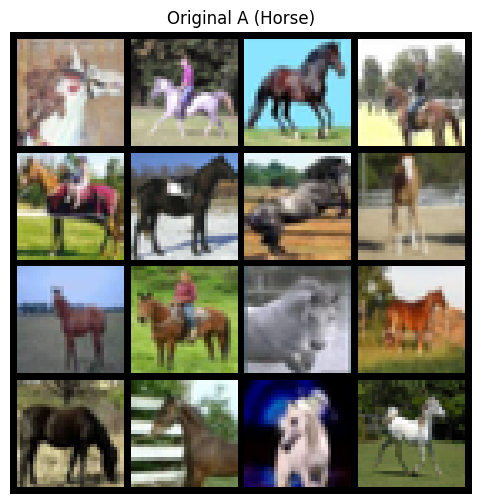

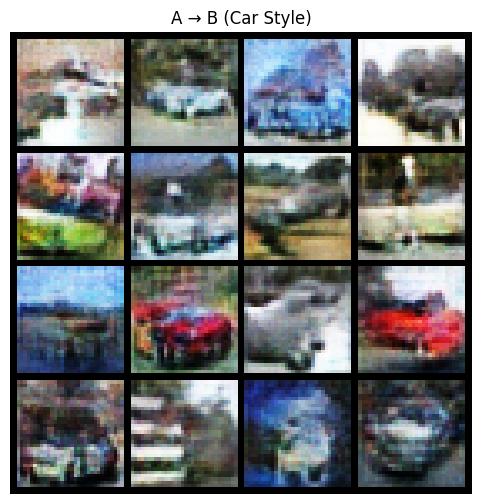

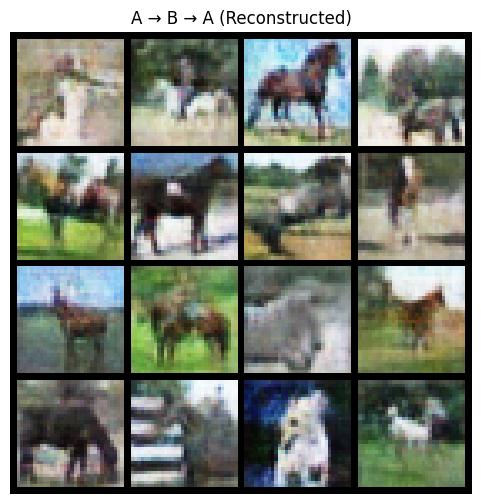

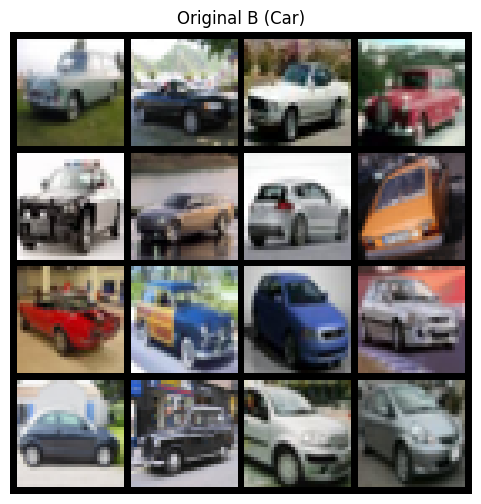

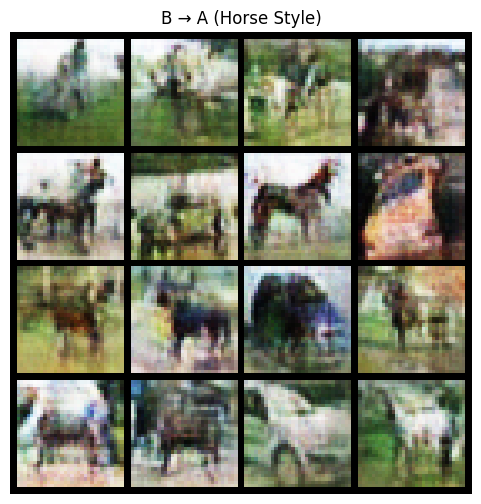

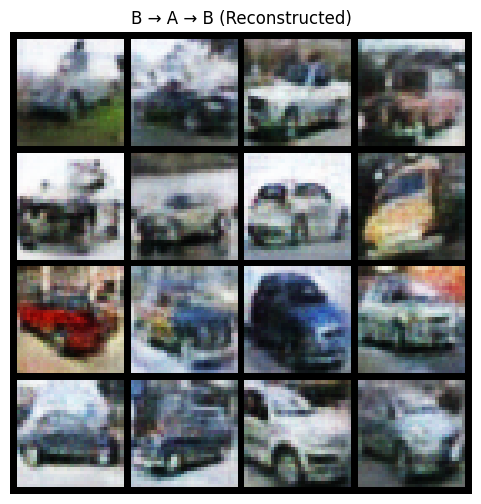

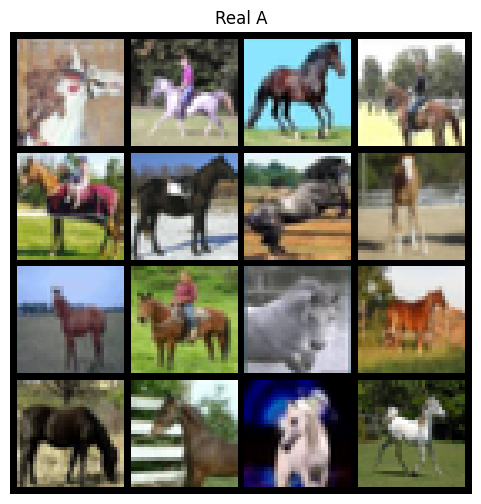

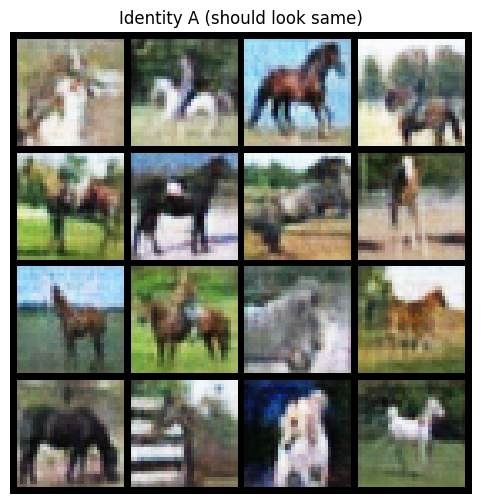

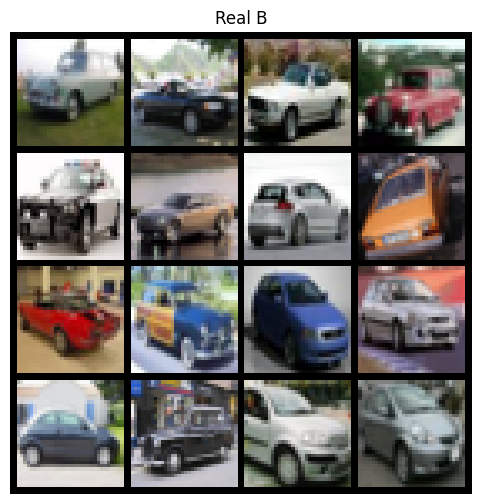

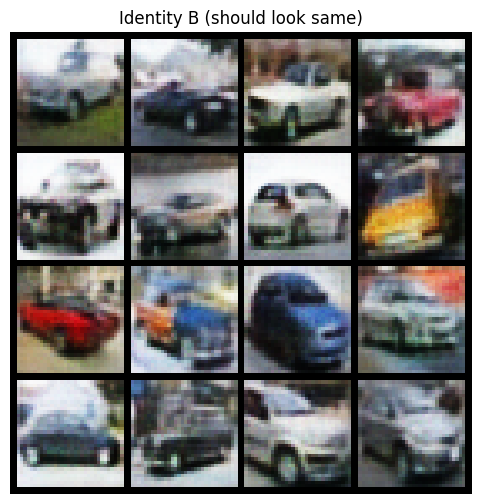

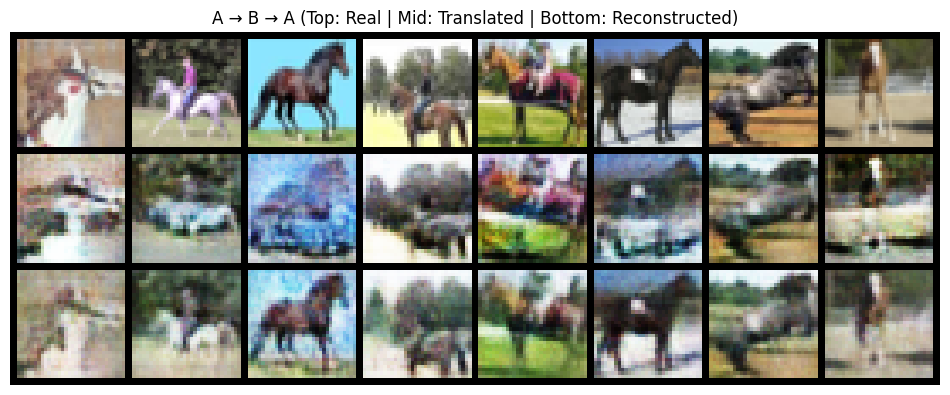

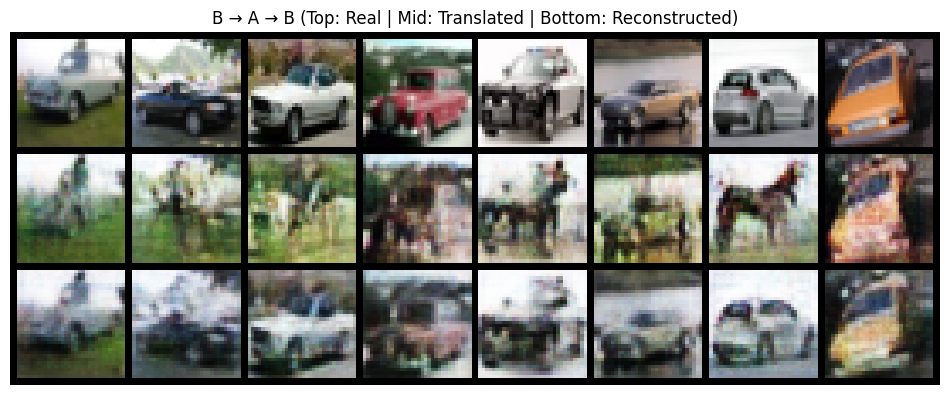

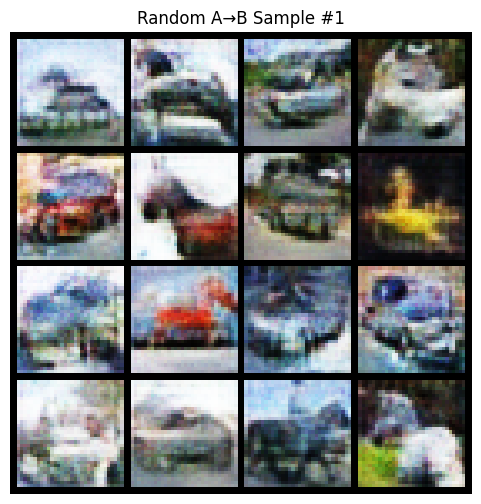

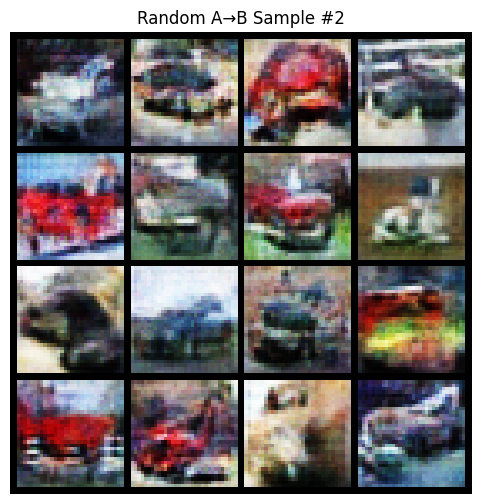

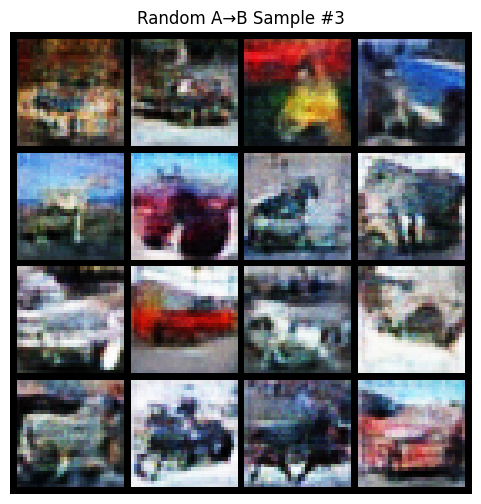

In [ ]:
# ==========================================
# Advanced Visualization for CycleGAN
# ==========================================

import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===== Helper =====
def denorm(x):
    return x * 0.5 + 0.5

def show_grid(tensors, title, nrow=4):
    grid = make_grid(denorm(tensors[:16].cpu()), nrow=nrow)
    plt.figure(figsize=(6,6))
    plt.imshow(grid.permute(1,2,0))
    plt.title(title)
    plt.axis('off')

# ==========================================
# 1. A → B → A (Cycle Consistency Visualization)
# ==========================================
real_A = next(iter(loader_A)).to(device)

with torch.no_grad():
    fake_B = G_AB(real_A)
    rec_A = G_BA(fake_B)

show_grid(real_A, "Original A (Horse)")
show_grid(fake_B, "A → B (Car Style)")
show_grid(rec_A, "A → B → A (Reconstructed)")

# ==========================================
# 2. B → A → B
# ==========================================
real_B = next(iter(loader_B)).to(device)

with torch.no_grad():
    fake_A = G_BA(real_B)
    rec_B = G_AB(fake_A)

show_grid(real_B, "Original B (Car)")
show_grid(fake_A, "B → A (Horse Style)")
show_grid(rec_B, "B → A → B (Reconstructed)")

# ==========================================
# 3. Identity Mapping (should preserve image)
# ==========================================
with torch.no_grad():
    id_A = G_BA(real_A)
    id_B = G_AB(real_B)

show_grid(real_A, "Real A")
show_grid(id_A, "Identity A (should look same)")

show_grid(real_B, "Real B")
show_grid(id_B, "Identity B (should look same)")

# ==========================================
# 4. Side-by-side comparison (BEST VIEW)
# ==========================================
def compare_triplet(real, translated, reconstructed, title):
    combined = torch.cat([real[:8], translated[:8], reconstructed[:8]], dim=0)
    grid = make_grid(denorm(combined.cpu()), nrow=8)
    plt.figure(figsize=(12,6))
    plt.imshow(grid.permute(1,2,0))
    plt.title(title + " (Top: Real | Mid: Translated | Bottom: Reconstructed)")
    plt.axis('off')

compare_triplet(real_A, fake_B, rec_A, "A → B → A")
compare_triplet(real_B, fake_A, rec_B, "B → A → B")

# ==========================================
# 5. Random Sampling (different batches)
# ==========================================
for i in range(3):
    real_A = next(iter(loader_A)).to(device)
    with torch.no_grad():
        fake_B = G_AB(real_A)

    show_grid(fake_B, f"Random A→B Sample #{i+1}")

# ==========================================
# 6. Save outputs (optional)
# ==========================================
import os
os.makedirs("outputs", exist_ok=True)

def save_images(tensor, filename):
    grid = make_grid(denorm(tensor.cpu()), nrow=4)
    plt.imsave(filename, grid.permute(1,2,0).numpy())

save_images(fake_B, "outputs/sample_A_to_B.png")
save_images(fake_A, "outputs/sample_B_to_A.png")

print("Saved some outputs to ./outputs/")